# 01 — Exploratory Data Analysis

Goal: understand the dataset structure, distributions, and relationships before any transformation.

**Dataset:** `data/starbucks_customer_ordering_patterns.csv`  
**Rows:** 100,000 | **Columns:** 20 | **Nulls:** none

## 1. Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 20)


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


## 2. Schema overview

Check column types and confirm there are no missing values.

In [2]:
df.dtypes

customer_id                  str
order_id                     str
order_date                   str
order_time                   str
day_of_week                  str
order_channel                str
store_id                     str
store_location_type          str
region                       str
customer_age_group           str
customer_gender              str
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category               str
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64
dtype: object

In [3]:
df.isnull().sum()

customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64

## 3. Numeric variables — distributions

We inspect the five quantitative features we'll use in the models:
- `cart_size`: number of items in the order (1–10)
- `num_customizations`: number of modifications to the order (0–8)
- `total_spend`: transaction total in USD
- `fulfillment_time_min`: preparation + wait time in minutes
- `customer_satisfaction`: customer rating 1–5 (this will be our target variable)

In [4]:
numeric_cols = ['cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 'customer_satisfaction']
df[numeric_cols].describe().round(2)

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,3.74,1.81,14.87,4.55,3.69
std,1.70,1.46,5.51,1.55,1.18
min,1.00,0.00,3.51,1.00,1.00
25%,3.00,1.00,10.84,3.40,3.00
50%,4.00,2.00,14.17,4.40,4.00
75%,5.00,3.00,18.18,5.50,5.00
max,10.00,8.00,40.31,11.20,5.00


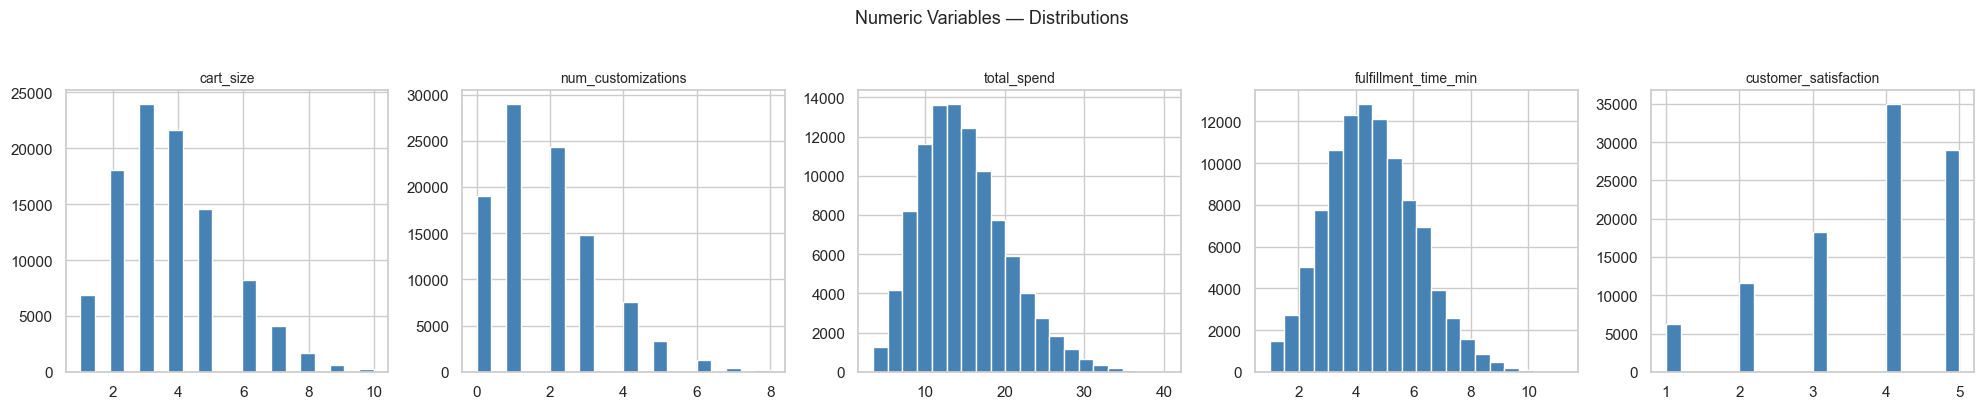

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Numeric Variables — Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Categorical variables — value counts

We check the distribution of each categorical feature to detect imbalances that could affect the models.

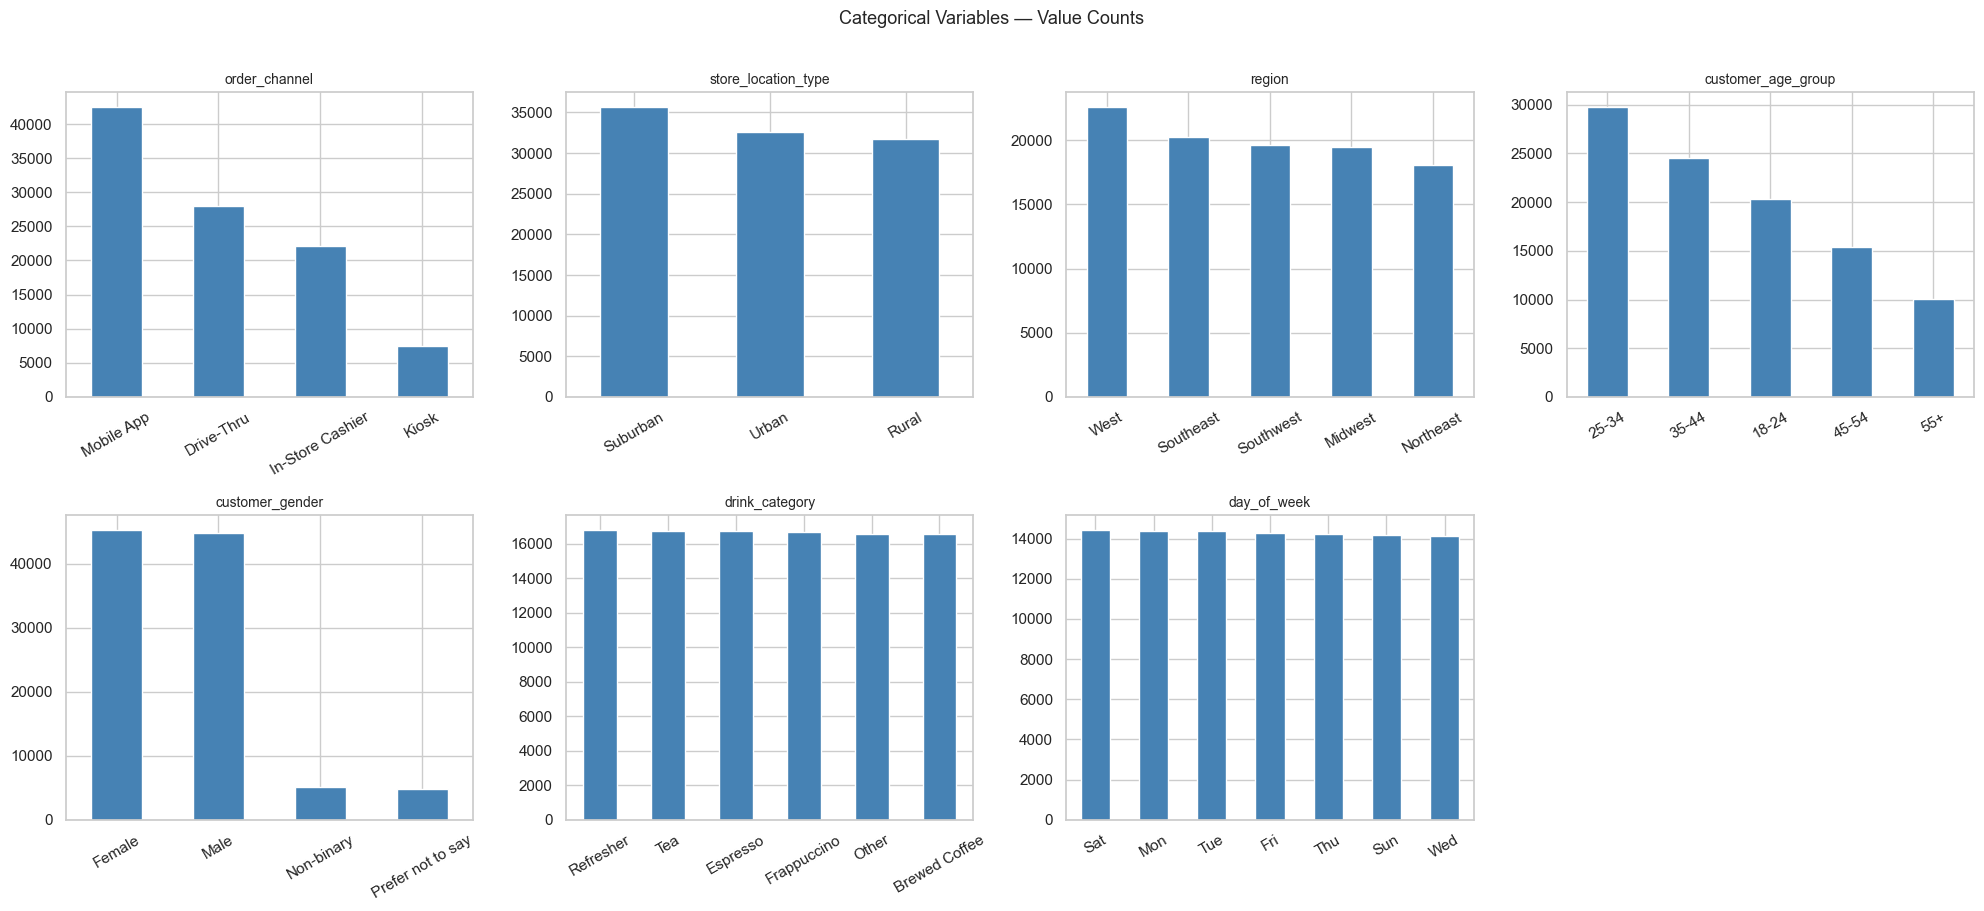

In [6]:
categorical_cols = ['order_channel', 'store_location_type', 'region',
                    'customer_age_group', 'customer_gender', 'drink_category', 'day_of_week']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Categorical Variables — Value Counts', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Boolean variables

Three binary flags in the dataset:
- `is_rewards_member`: whether the customer is enrolled in the Starbucks rewards program
- `has_food_item`: whether the order included a food item
- `order_ahead`: whether the order was placed in advance via mobile

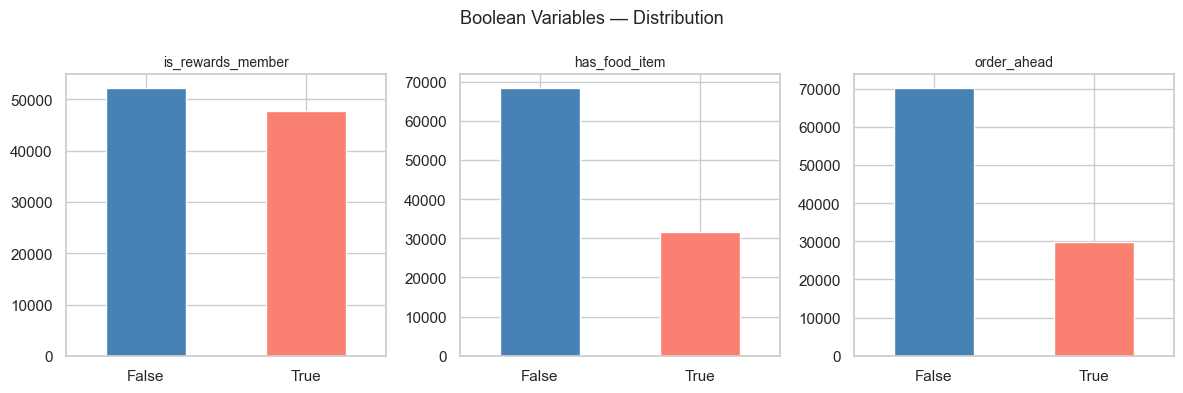

In [7]:
bool_cols = ['is_rewards_member', 'has_food_item', 'order_ahead']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, bool_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Boolean Variables — Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Target variable: `customer_satisfaction`

We analyse the distribution of satisfaction scores (1–5) and preview the split we will apply in preprocessing:
- **High** (≥ 4): satisfied customers
- **Low** (≤ 3): unsatisfied customers

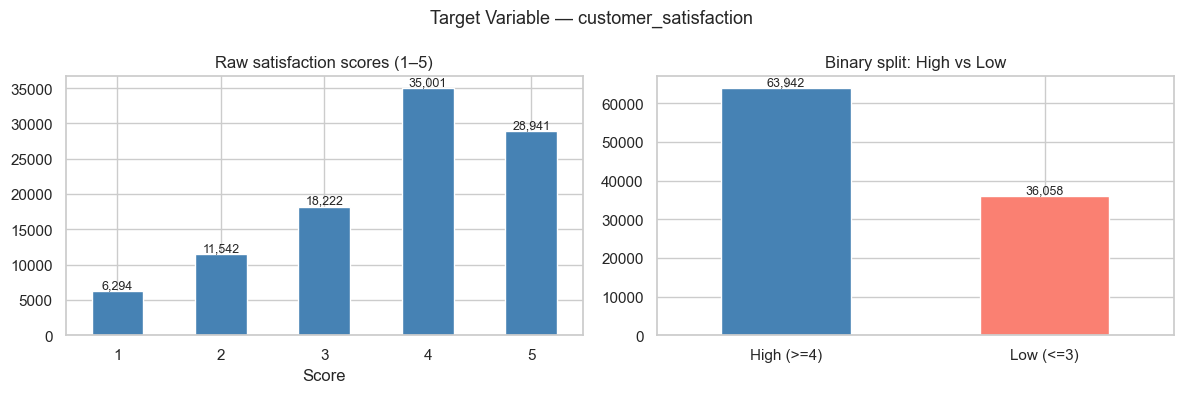

High (>=4): 63,942 (63.9%)
Low  (<=3): 36,058 (36.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw score distribution
df['customer_satisfaction'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Raw satisfaction scores (1–5)')
axes[0].set_xlabel('Score')
axes[0].tick_params(axis='x', rotation=0)

# Binary split preview
binary = df['customer_satisfaction'].apply(lambda x: 'High (>=4)' if x >= 4 else 'Low (<=3)')
binary.value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white'
)
axes[1].set_title('Binary split: High vs Low')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Target Variable — customer_satisfaction', fontsize=13)
plt.tight_layout()
plt.show()

print(f"High (>=4): {(df['customer_satisfaction'] >= 4).sum():,} ({(df['customer_satisfaction'] >= 4).mean():.1%})")
print(f"Low  (<=3): {(df['customer_satisfaction'] <= 3).sum():,} ({(df['customer_satisfaction'] <= 3).mean():.1%})")

## 7. Correlation matrix

We check linear correlations between numeric variables. This confirms findings from the DW TP: `num_customizations` and `fulfillment_time_min` have near-zero correlation.

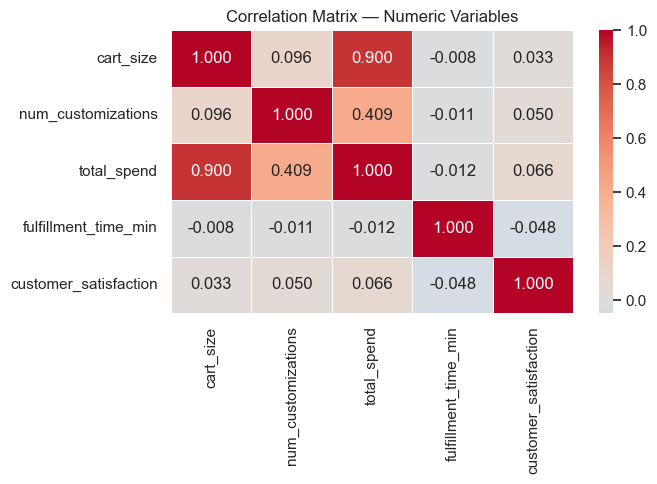

In [9]:
corr = df[numeric_cols].corr().round(3)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

## 8. Channel vs fulfillment time

Replicating the key DW TP finding to verify it holds in the raw dataset before any transformation.

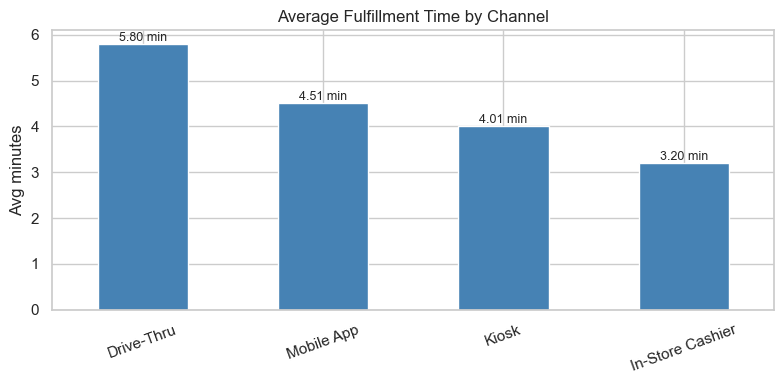

In [10]:
channel_avg = df.groupby('order_channel')['fulfillment_time_min'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = channel_avg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Fulfillment Time by Channel')
plt.ylabel('Avg minutes')
plt.xlabel('')
plt.xticks(rotation=20)
for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f} min', (p.get_x() + p.get_width() / 2, p.get_height()),
                  ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Channel vs customer satisfaction

We check whether the slowest channel also correlates with lower satisfaction scores.

C:\Users\Denise\AppData\Local\Temp\ipykernel_21436\690316994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='order_channel', y='customer_satisfaction', palette='Blues')


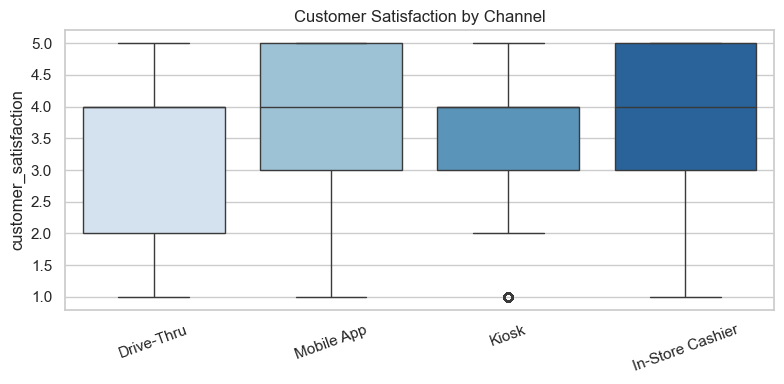

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='order_channel', y='customer_satisfaction', palette='Blues')
plt.title('Customer Satisfaction by Channel')
plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Fulfillment time vs satisfaction

Direct scatter to check if longer wait times push satisfaction down.

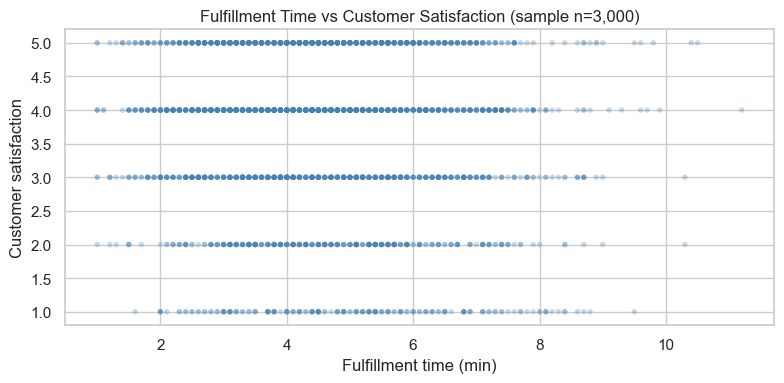

In [12]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(8, 4))
plt.scatter(sample['fulfillment_time_min'], sample['customer_satisfaction'],
            alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.xlabel('Fulfillment time (min)')
plt.ylabel('Customer satisfaction')
plt.title('Fulfillment Time vs Customer Satisfaction (sample n=3,000)')
plt.tight_layout()
plt.show()

---
## EDA Summary

| Finding | Detail |
|---|---|
| No missing values | Dataset is complete, no imputation needed |
| Target class balance | High (≥4): ~64% / Low (≤3): ~36% — mild imbalance, acceptable |
| Drive-Thru is slowest | Confirmed: 5.79 min avg vs 3.22 min baseline (DW finding holds) |
| Customizations ↔ delay | Near-zero correlation (confirmed from DW TP) |
| drink_category | Perfectly balanced across 6 categories (~16.7k each) |
| Booleans | All three flags reasonably balanced (no extreme skew) |

**Next step:** `02_preprocessing.ipynb` — clean, encode, discretize, and export ARFF for WEKA.